<a href="https://colab.research.google.com/github/benito1TIA/Statistika/blob/main/Codingan_Statistika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tabel Frekuensi:
col_0  Frekuensi
Grade           
A             12
AB             7
B              4
BC             1
C              5
F              1


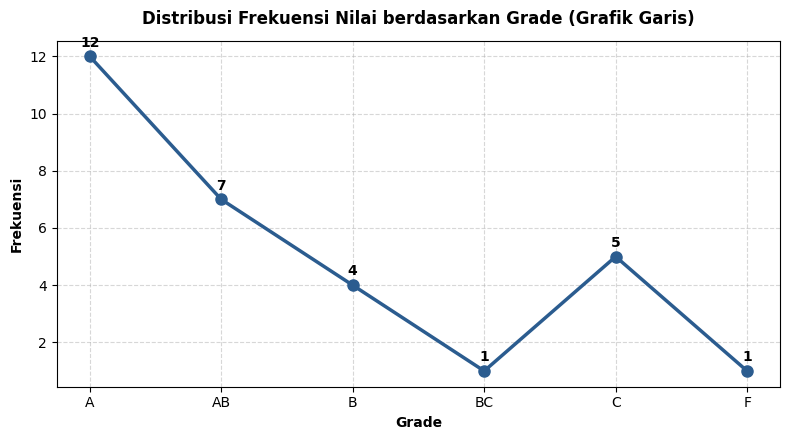

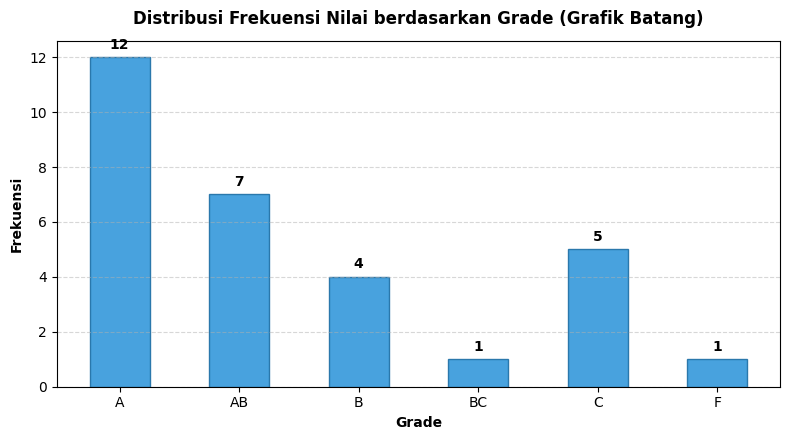

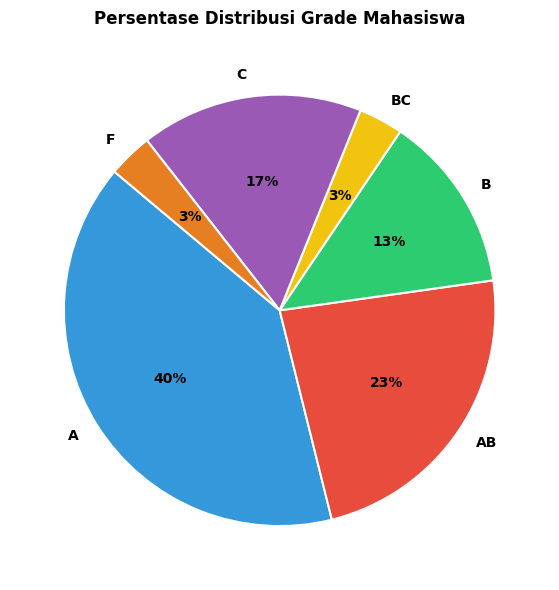


Statistika Deskriptif:
count              30.000000
mean               76.221333
std                13.466585
min                46.010000
25%                68.095000
50%                78.800000
75%                87.040000
max                94.030000
Standard Error      2.458651
Median             78.800000
Mode               77.300000
variance          181.348922
range              48.020000
skewness           -0.664190
kurtosis           -0.527463
Name: Final Score, dtype: float64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt


path = "DataScore.xlsx"
dataraw = pd.read_excel(path)


datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
print("Tabel Frekuensi:")
print(datafrq)


custom_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#9b59b6', '#e67e22']




plt.figure(figsize=(8, 4.5))
plt.plot(datafrq.index, datafrq["Frekuensi"], marker='o', color='#2b5c8f', linewidth=2.5, markersize=8)
plt.title("Distribusi Frekuensi Nilai berdasarkan Grade (Grafik Garis)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Grade", fontsize=10, fontweight='bold')
plt.ylabel("Frekuensi", fontsize=10, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)


for i, val in enumerate(datafrq["Frekuensi"]):
    plt.annotate(str(val), (datafrq.index[i], val), textcoords="offset points", xytext=(0, 7), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Grafik Batang (Bar Chart)
plt.figure(figsize=(8, 4.5))
bars = plt.bar(datafrq.index, datafrq["Frekuensi"], color='#3498db', edgecolor='#1d6fa5', width=0.5, alpha=0.9)
plt.title("Distribusi Frekuensi Nilai berdasarkan Grade (Grafik Batang)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Grade", fontsize=10, fontweight='bold')
plt.ylabel("Frekuensi", fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 6))
plt.pie(
    datafrq["Frekuensi"],
    labels=datafrq.index,
    autopct='%1.0f%%',
    startangle=140,
    colors=custom_colors[:len(datafrq)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10, 'weight': 'bold'}
)
plt.title("Persentase Distribusi Grade Mahasiswa", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


dataraw["Final Score"] = pd.to_numeric(dataraw["Final Score"], errors='coerce')
dt = dataraw["Final Score"]
stats = dt.describe()
stats['Standard Error'] = dt.sem()
stats['Median'] = dt.median()
stats['Mode'] = dt.mode().iloc[0]
stats['variance'] = dt.var()
stats['range'] = dt.max() - dt.min()
stats['skewness'] = dt.skew()
stats['kurtosis'] = dt.kurtosis()

print("\nStatistika Deskriptif:")
print(stats)